# Análise de churn — EDA e baseline

Nesta etapa vamos conhecer a base, verificar possíveis problemas de qualidade e treinar uma Regressão Logística como primeiro modelo de referência.


## ML Canvas

O ML Canvas resume como o problema de negócio será transformado em um projeto de Machine Learning.

| Item | Definição para este projeto |
|---|---|
| Problema de negócio | A operadora precisa identificar clientes com maior risco de cancelamento para organizar ações de retenção. |
| Objetivo do modelo | Estimar a probabilidade de churn de cada cliente. |
| Público interessado | Retenção, CRM, marketing, atendimento, gestão e equipe de dados. |
| Dados de entrada | Informações cadastrais, tempo de relacionamento, serviços contratados, contrato, mensalidade, cobrança total e método de pagamento. |
| Variável-alvo | `Churn`, com as classes `Yes` e `No`. |
| Saída do modelo | Classe prevista e probabilidade estimada de churn. |
| Decisão apoiada | Ordenar os clientes por risco e priorizar os casos mais relevantes. |
| Métricas técnicas | F1-score, recall, precision, ROC-AUC, acurácia e matriz de confusão. |
| Métricas de priorização | Capture Rate@30% e Lift@30%. |
| Riscos | Erros de classificação, mudança no comportamento dos clientes e limitações dos dados históricos. |

### Metas iniciais

- ROC-AUC maior ou igual a 0,80;
- F1-score maior ou igual a 0,60;
- recall maior ou igual a 0,55;
- Capture Rate@30% maior ou igual a 0,60;
- Lift@30% maior ou igual a 2,00.

### Limitação dos dados

O dataset não possui informações sobre campanhas de retenção, ofertas, custos ou resultados financeiros. Portanto, ele permite avaliar a capacidade de **identificar e priorizar clientes**, mas não permite provar redução real de churn, receita preservada ou retorno financeiro.


In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 1. Leitura da base

In [2]:
nome_arquivo = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

candidatos = [
    Path("data/raw") / nome_arquivo,
    Path("../data/raw") / nome_arquivo,
    Path("../../data/raw") / nome_arquivo,
]

DATA_PATH = next((p.resolve() for p in candidatos if p.exists()), None)

if DATA_PATH is None:
    from tkinter import Tk, filedialog

    root = Tk()
    root.withdraw()
    root.attributes("-topmost", True)

    arquivo = filedialog.askopenfilename(
        title="Selecione o arquivo de churn",
        filetypes=[("Arquivos CSV", "*.csv")],
    )

    root.destroy()

    if not arquivo:
        raise FileNotFoundError("O arquivo não foi selecionado.")

    DATA_PATH = Path(arquivo)


In [3]:
df = pd.read_csv(DATA_PATH)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Visão geral

In [4]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
print("Clientes únicos:", df["customerID"].nunique())

df.info()


Linhas: 7043
Colunas: 21
Clientes únicos: 7043
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 


## 3. Qualidade dos dados

In [5]:
dados = df.copy()

# A coluna vem como texto porque há alguns espaços em branco
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")

qualidade = pd.DataFrame({
    "tipo": dados.dtypes.astype(str),
    "nulos": dados.isna().sum(),
    "valores_unicos": dados.nunique(dropna=False),
})

qualidade


,tipo,nulos,valores_unicos
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3


In [6]:
print("Linhas duplicadas:", dados.duplicated().sum())
print("IDs duplicados:", dados["customerID"].duplicated().sum())
print("Nulos em TotalCharges:", dados["TotalCharges"].isna().sum())


Linhas duplicadas: 0
IDs duplicados: 0
Nulos em TotalCharges: 11


Foram encontrados 11 valores ausentes em `TotalCharges`. O preenchimento será feito pela mediana dentro do pipeline, evitando tratar o conjunto de teste com informações do conjunto de treino.


## 4. Variável alvo

In [7]:
resumo_churn = pd.DataFrame({
    "quantidade": dados["Churn"].value_counts(),
    "percentual": dados["Churn"].value_counts(normalize=True).mul(100).round(2),
})

resumo_churn


,quantidade,percentual
Churn,,
No,5174,73.46
Yes,1869,26.54


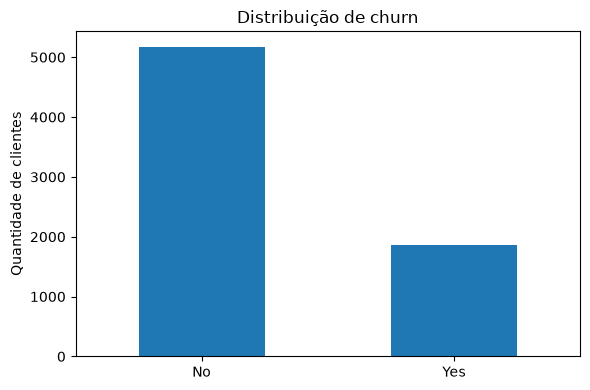

In [8]:
ax = dados["Churn"].value_counts().plot(kind="bar", figsize=(6, 4))
ax.set_title("Distribuição de churn")
ax.set_xlabel("")
ax.set_ylabel("Quantidade de clientes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


A classe positiva representa cerca de 26,5% da base. Por esse motivo, a acurácia será analisada junto com recall, precision, F1-score e ROC-AUC.


## 5. Variáveis numéricas

In [9]:
colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
dados[colunas_numericas].describe().T


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


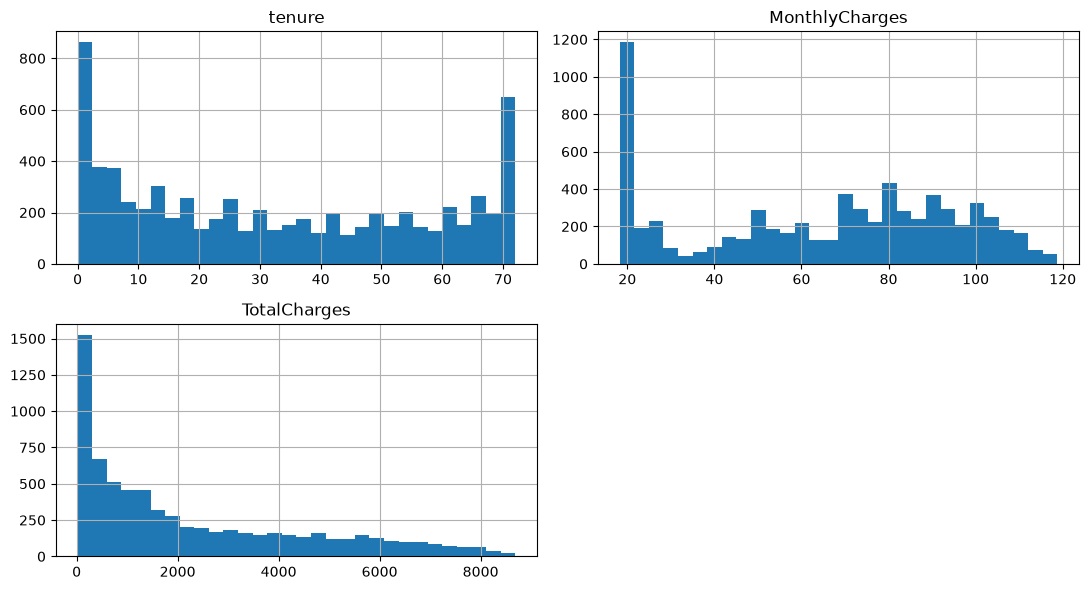

In [10]:
dados[colunas_numericas].hist(bins=30, figsize=(11, 6))
plt.tight_layout()
plt.show()


In [11]:
dados.groupby("Churn")[colunas_numericas].mean().round(2)


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


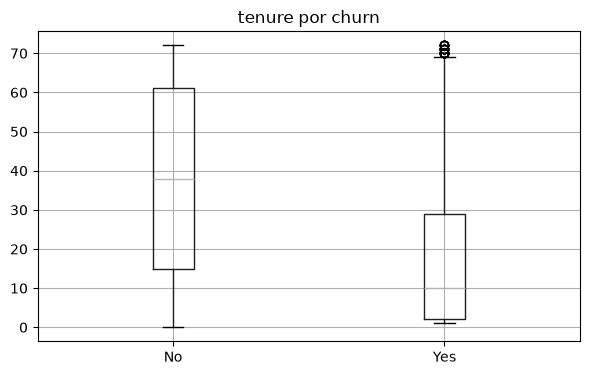

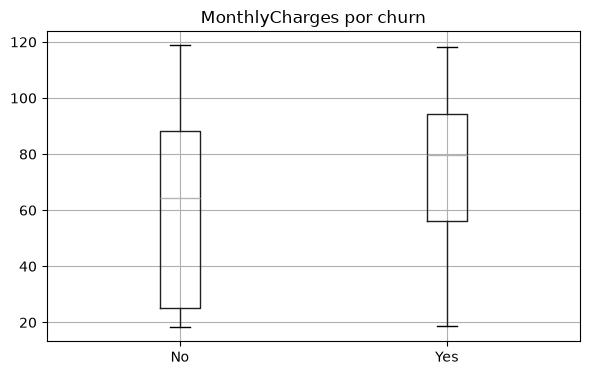

In [12]:
for coluna in ["tenure", "MonthlyCharges"]:
    dados.boxplot(column=coluna, by="Churn", figsize=(6, 4))
    plt.title(f"{coluna} por churn")
    plt.suptitle("")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()


## 6. Variáveis categóricas

In [13]:
def taxa_churn_por(coluna):
    return (
        dados.assign(churn_flag=(dados["Churn"] == "Yes").astype(int))
        .groupby(coluna)["churn_flag"]
        .mean()
        .sort_values(ascending=False)
    )

taxa_churn_por("Contract")


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: churn_flag, dtype: float64

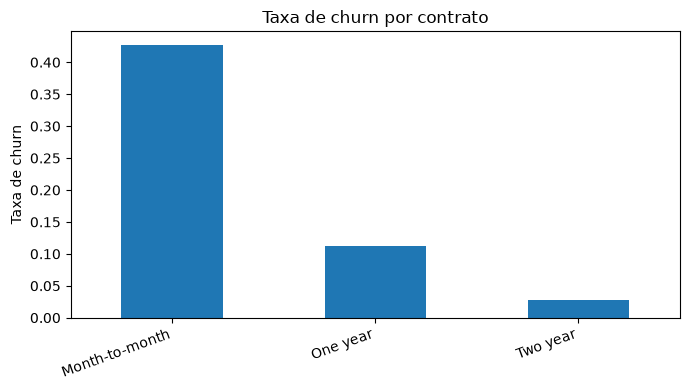

In [14]:
taxa_churn_por("Contract").plot(kind="bar", figsize=(7, 4))
plt.title("Taxa de churn por contrato")
plt.xlabel("")
plt.ylabel("Taxa de churn")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


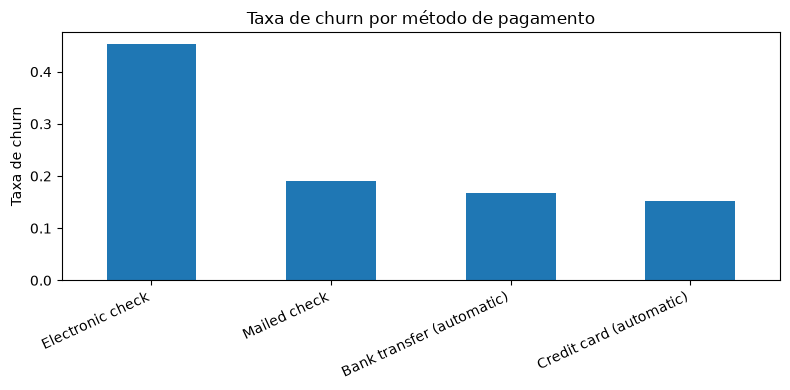

In [15]:
taxa_churn_por("PaymentMethod").plot(kind="bar", figsize=(8, 4))
plt.title("Taxa de churn por método de pagamento")
plt.xlabel("")
plt.ylabel("Taxa de churn")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Principais observações

- clientes com contrato mensal apresentam uma taxa de churn maior;
- clientes que cancelaram têm menor tempo médio de relacionamento;
- a mensalidade média é maior entre clientes que cancelaram;
- o método de pagamento por cheque eletrônico aparece com maior taxa de churn.

Essas relações ajudam a entender a base, mas não provam causalidade.


## 7. Preparação dos dados

In [16]:
X = dados.drop(columns=["customerID", "Churn"])
y = dados["Churn"].map({"No": 0, "Yes": 1})

features_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
features_categoricas = [c for c in X.columns if c not in features_numericas]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (5634, 19)
Teste: (1409, 19)


## 8. Regressão Logística

In [17]:
tratamento_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

tratamento_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessamento = ColumnTransformer([
    ("num", tratamento_numerico, features_numericas),
    ("cat", tratamento_categorico, features_categoricas),
])

modelo = Pipeline([
    ("preprocessamento", preprocessamento),
    ("classificador", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

modelo.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

## 9. Avaliação

In [18]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

metricas = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

pd.DataFrame([metricas]).round(4)


,accuracy,precision,recall,f1_score,roc_auc
0,0.8055,0.6572,0.5588,0.604,0.8419


In [19]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Não churn", "Churn"],
))


              precision    recall  f1-score   support

   Não churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



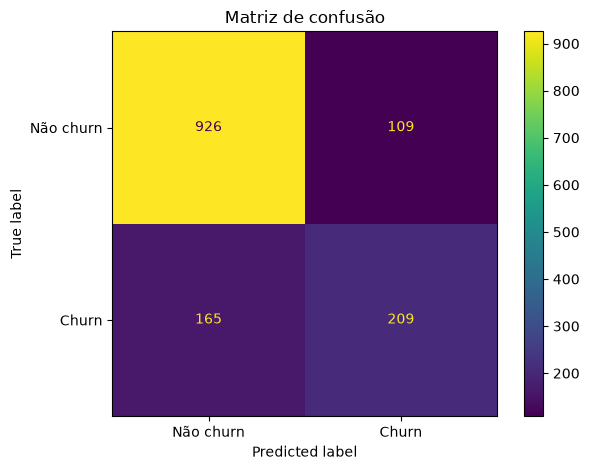

array([[926, 109],
       [165, 209]])

In [20]:
matriz = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Não churn", "Churn"],
).plot()

plt.title("Matriz de confusão")
plt.tight_layout()
plt.show()

matriz


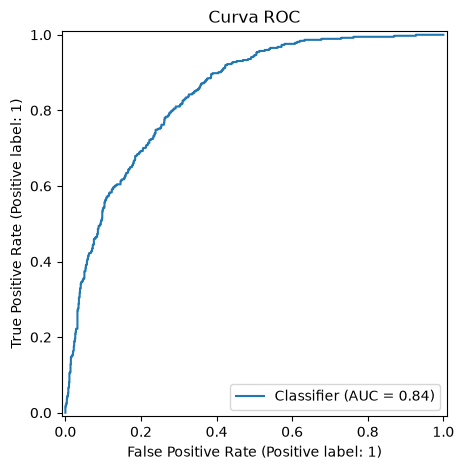

In [21]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC")
plt.tight_layout()
plt.show()


## 10. Métricas de priorização

In [22]:
ranking = pd.DataFrame({
    "churn_real": y_test.to_numpy(),
    "probabilidade": y_proba,
}).sort_values("probabilidade", ascending=False)

n_priorizados = int(np.ceil(len(ranking) * 0.30))
top_30 = ranking.head(n_priorizados)

capture_rate_30 = top_30["churn_real"].sum() / ranking["churn_real"].sum()
lift_30 = top_30["churn_real"].mean() / ranking["churn_real"].mean()

metricas_priorizacao = {
    "clientes_priorizados": n_priorizados,
    "churns_capturados": int(top_30["churn_real"].sum()),
    "capture_rate_30": capture_rate_30,
    "lift_30": lift_30,
}

pd.DataFrame([metricas_priorizacao]).round(4)


,clientes_priorizados,churns_capturados,capture_rate_30,lift_30
0,423,243,0.6497,2.1642


O modelo consegue concentrar aproximadamente 65% dos churns reais nos 30% de clientes com maior probabilidade prevista. O lift próximo de 2,16 indica que esse grupo tem uma concentração de churn mais de duas vezes maior do que a média.


## 11. Salvando os resultados

In [23]:
# A raiz do projeto é obtida a partir da pasta data/raw
PROJECT_ROOT = DATA_PATH.parent.parent.parent

(PROJECT_ROOT / "models").mkdir(exist_ok=True)
(PROJECT_ROOT / "reports/metrics").mkdir(parents=True, exist_ok=True)

joblib.dump(modelo, PROJECT_ROOT / "models/logistic_regression.joblib")

with open(PROJECT_ROOT / "reports/metrics/metricas.json", "w", encoding="utf-8") as arquivo:
    json.dump(
        {
            **{k: float(v) for k, v in metricas.items()},
            **{
                "clientes_priorizados": int(metricas_priorizacao["clientes_priorizados"]),
                "churns_capturados": int(metricas_priorizacao["churns_capturados"]),
                "capture_rate_30": float(metricas_priorizacao["capture_rate_30"]),
                "lift_30": float(metricas_priorizacao["lift_30"]),
            },
        },
        arquivo,
        indent=2,
        ensure_ascii=False,
    )

print("Modelo e métricas salvos.")


Modelo e métricas salvos.


## Conclusão

A Regressão Logística apresentou um bom resultado como baseline, principalmente em ROC-AUC. O recall ainda deixa parte dos clientes com churn sem identificação, então a próxima etapa deve comparar esse resultado com outros modelos e avaliar possíveis ajustes de limiar.
